# ESDA2 Individual Project Part 1 – Santorini [50 marks]

This first part of the individual project is similar in style to most of the notebooks you worked on during the practicals, where we ask you to work through a structured set of tasks. Each task is marked as Fundamentals, Core, or Advanced, and the marks allocated to each task are given in square brackets. This part of the project is roughly 60% Fundamentals, 25% Core, and 15% Advanced; Part 2 is more heavily weighted towards Advanced, with Core split equally between them.

**This assignment should be done entirely individually.** You may use the Jupyternaut AI, python package manuals, and other online resources (not including asking people online or other online AI) to help with your coding, but make sure your code is clearly commented showing what each section does. You should be able to explain what each line does if asked. 

In this assessment we want to see the process you go through for data analysis – a significant portion of the marks are allocated to how you explain the steps you took, why you took them, and your interpretation of the results. **Correct code on its own is not sufficient.** That also means that if you can explain what you want to do and why, you can receive partial credit for that part of the data analysis, even without being able to code it up. 

If you cannot get part of the code to work, you can maximise your partial credit by explaining what you are trying to do, your understanding of what is not working, and what you have tried to fix it.

If you cannot get one of the files to load, please ask Lara. Depending on the amount of help required, this will reduce the marks you can get for the actual file import, but we do not want you unable to even attempt large sections of the assignment due to initial file problems.

In [26]:
# package required for colour maps later of topography data
!pip install cmocean

In [27]:
import sys
!{sys.executable} -m pip install basemap

In [28]:
import sys
!{sys.executable} -m pip install netCDF4


In [29]:
# Load the libraries you need using the standard aliases. Add to this as you work through the notebook.
#Also set up a variable with the absolute path to the shared data directory.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from mpl_toolkits.basemap import Basemap
import netCDF4 as nc
from matplotlib.colors import LightSource
import cmocean
from matplotlib.path import Path
import seaborn as sns

# set path to data directory
project_data_path = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'data') + os.sep
print(project_data_path)

c:\Users\JoelM\OneDrive - University of Edinburgh\Year 2\Earth Science Data Analysis 2\ESDA2_Project2\data\


## Section 1 – Initial exploration of the study area

In this notebook, we will be exploring the eruption history of the Santorini volcano.

- **Fundamentals: [3]** Research Santorini and write a paragraph introduction to the volcano and its history from a geohazards perspective.
- **Fundamentals: [2]** Produce a regional map showing Santorini. Show country boundaries and label a couple key countries to help orient the reader. Mark and label Santorini. Think about your use of colour, line weight, and text size to produce an effective, professional-looking figure. Your map should be static, suitable for printing.


**Answer:**

Located on the Hellenic Volcanic Arc, Santorini is a volcanic field driven by the subduction of the African plate under the Eurasian plate. Geologically, the island was formed by a `caldera cycle', a repeating process of growth, eruption and collapse. The last major eruption was the Minoan Eruption (c. 1600 BC), which was one of the largest volcanic events in human history; it had a VEI of 7, and expelled an estimated $28\text{-}41 \text{ km}^3$ DRE of material. This eruption also caused major ash fall, tsunamis and pyroclastic density currents. Although the central islands Palea Kameni and Nea Kameni are currently dormant, Santorini remains an active volcano, having last erupted in 1950. This means there is still a possibility of renewed volcanic eruptions. While likely not to the scale of the Minoan eruptions, there is a continued risk of tsunamis and ashfall from eruption, and water heating and volcanic gas emission which can impact water and air quality. 

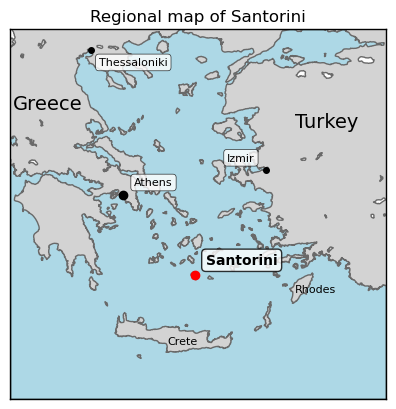

In [30]:
# regional map of santorini

# set up basemap in mercator projection (small scale closer to equator)
# bounding coordinates include geographical context
m = Basemap(
    projection='merc', # mercator projection
    llcrnrlat=34,    # lower left corner latitude
    urcrnrlat=41,    # upper right corner latitude
    llcrnrlon=21,    # lower left corner longitude
    urcrnrlon=30,    # upper right corner longitude
    resolution='h'      # high resolution
)

# customise map
m.drawcoastlines(color='dimgray') # draw coastlines
m.fillcontinents(color='lightgray') # land
m.drawmapboundary(fill_color='lightblue') # ocean

# plot marker on santorini and add label
x_santorini, y_santorini = m(25.412362, 36.425080) 
m.plot(x_santorini, y_santorini, marker='o', markersize=6, color='red') # red marker on santorini
plt.text(x_santorini+30000, y_santorini+20000, 'Santorini', fontsize=10, weight='bold', ha='left', va='bottom',
         bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', alpha=0.8)) # add label

# add label on greece
x_greece, y_greece = m(21.077924, 39.546625)
plt.text(x_greece, y_greece, 'Greece', fontsize=14)

# add label on turkey
x_turkey, y_turkey = m(27.823911, 39.212273)
plt.text(x_turkey, y_turkey, 'Turkey', fontsize=14)

# add label on crete
x_crete, y_crete = m(24.769830, 35.084951)
plt.text(x_crete, y_crete, 'Crete', fontsize=8)

# add label on rhodes
x_rhodes, y_rhodes = m(27.812187, 36.094197)
plt.text(x_rhodes, y_rhodes, 'Rhodes', fontsize=8)

# marker and label for athens
x_athens, y_athens = m(23.698682, 37.944448) 
m.plot(x_athens, y_athens, marker='o', markersize=6, color='black')
plt.text(x_athens+30000, y_athens+20000, 'Athens', fontsize=8, ha='left', va='bottom',
         bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', alpha=0.8, lw=0.5))

# marker and label for izmir
x_izmir, y_izmir = m(27.119915, 38.409373) 
m.plot(x_izmir, y_izmir, marker='o', markersize=4, color='black')
plt.text(x_izmir-30000, y_izmir+20000, 'Izmir', fontsize=8, ha='right', va='bottom',
         bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', alpha=0.8, lw=0.5))

# marker and label for thessaloniki
x_thess, y_thess = m(22.945772, 40.62893) 
m.plot(x_thess, y_thess, marker='o', markersize=4, color='black')
plt.text(x_thess+20000, y_thess-20000, 'Thessaloniki', fontsize=8, ha='left', va='top',
         bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', alpha=0.8, lw=0.5))


plt.title('Regional map of Santorini')
plt.show()

## Section 2: Topography and Bathymetry of Santorini

The file `santorini_surf_smooth.nc' in the shared data directory contains high resolution topography and bathymetry for the area around Santorini Caldera. 

- **Fundamentals: [2]** Go through the process of loading this data, inspecting its variables, and extracting them to numpy arrays, explaining what you are doing and why at each step.

In [31]:
# get path to file
file_path = project_data_path + 'santorini_surf_smooth.nc'

# read dataset
ds = nc.Dataset(file_path)

# print the dataset info - we see it contains high resolution gridded data for santorini
print(ds)

<class 'netCDF4.Dataset'>
root group (NETCDF3_CLASSIC data model, file format NETCDF3):
    Conventions: COARDS/CF-1.0
    title: surface
    history: grdfilter santorini_surf.grd -Gsantorini_surf_smouth.grd -D4 -Fm0.05
    GMT_version: 4.5.9 [64-bit]
    dimensions(sizes): x(2985), y(3337)
    variables(dimensions): float64 x(x), float64 y(y), float32 z(y, x)
    groups: 


In [32]:
# print information on the variables to see dimensions, shape, range and dependancy
print(ds.variables)

{'x': <class 'netCDF4.Variable'>
float64 x(x)
    long_name: x
    actual_range: [25.15 25.65]
unlimited dimensions: 
current shape = (2985,)
filling on, default _FillValue of 9.969209968386869e+36 used, 'y': <class 'netCDF4.Variable'>
float64 y(y)
    long_name: y
    actual_range: [36.15 36.6 ]
unlimited dimensions: 
current shape = (3337,)
filling on, default _FillValue of 9.969209968386869e+36 used, 'z': <class 'netCDF4.Variable'>
float32 z(y, x)
    long_name: z
    _FillValue: nan
    actual_range: [-1546.9753418    555.63604736]
unlimited dimensions: 
current shape = (3337, 2985)
filling on}


In [33]:
# separate vairables into numpy arrays
x_elev = ds.variables['x'][:] # x values for grid data
y_elev = ds.variables['y'][:] # y values for grid data
elevation = ds.variables['z'][:,:] # elevation in grid

**Questions:**

- **Fundamentals: [1]** What do you think the units of x and y are? Why?
- **Fundamentals: [1]** What is the deepest depth in the area covered by the dataset?
- **Fundamentals: [1]** What is the spacing between points in x and y? What are sensible units for this?


**Answer:**

I think the units of x and y are degrees, as their respective ranges and use line up with the longitude and latitude of Santorini.

The deepest depth is -1546.98 m (2 d.p.). This is most likely in metres, as this is the standard scientific unit and the value in metres is reasonable.

Spacing in x is 0.000168 (3 s.f.). Spacing in y is 0.000135 (3 s.f.), currently assumed to be in degrees. A more sensible unit may be metres, as this is easy to understand, and is not distorted much for a small area. The values would also not be as small, instead being a more compreshensible amount.

In [34]:
print(f"Deepest depth: {elevation.flatten().min()}")

x_diff = np.diff(x_elev)
print(f"Difference in x: {x_diff.mean()}")

y_diff = np.diff(y_elev)
print(f"Difference in y: {y_diff.mean()}")

Deepest depth: -1546.975341796875
Difference in x: 0.0001675603217158177
Difference in y: 0.00013489208633093612


Now:

- **Fundamentals: [2]** Make a map of this topography data
- **Fundamentals: [1]** Add a colour bar
- **Fundamentals: [1]** Use contouring to plot a coastline
- **Advanced: [1]** Add a hillshade to allow us to see more detail

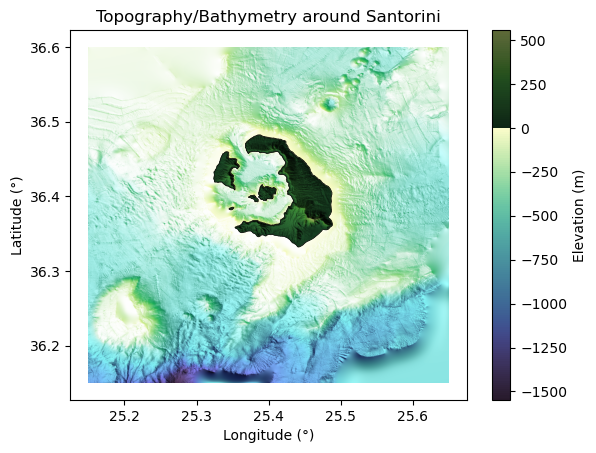

In [35]:
# find absolute maximum; set vmin and vmax to the +/- of this value to centre color map around zero 
max_abs_value = max(abs(elevation.flatten().min()), abs(elevation.flatten().max()))
vmin, vmax = -max_abs_value, max_abs_value

# colour map specifcally designed for bathmyerty data
cmap = cmocean.cm.topo

# create figure and axis
fig, ax = plt.subplots()

# plot a dummy variable of the colourmesh and remove; this is to get a colourbar
dummy = plt.pcolormesh(x_elev, y_elev, elevation, vmin=vmin, vmax=vmax, cmap=cmap)
dummy.remove()

# add hillshade 
ls = LightSource(azdeg=315, altdeg=45) # from northwest, at a 45 degree angle
# shade the elevation using same cmap as the colorbar and symmetric limits
hillshade = ls.shade(elevation, cmap=cmap, vmin=vmin, vmax=vmax, blend_mode='overlay') 
# show hillshade, with extent being the extent of the map
ax.imshow(hillshade, extent=[x_elev.min(), x_elev.max(), y_elev.min(), y_elev.max()], aspect='auto', origin='lower')

# add coastline using contouring (where elevation=0)
ax.contour(x_elev, y_elev, elevation, levels=[0], colors='black', linewidths=0.5)

# add colourbar with limits for only data we plot
cbar = plt.colorbar(dummy, label='Elevation (m)', ax=ax)
cbar.ax.set_ylim(elevation.flatten().min(), elevation.flatten().max())

# add labels
plt.title('Topography/Bathymetry around Santorini')
plt.ylabel('Latitude (°)')
plt.xlabel('Longitude (°)')
plt.show()

**Advanced: [2]** Now make a similar figure zoomed in just on the volcanic edifice of Santorini. Explain in detail how you used `np.where` to select the sections of x, y, and z to plot.

*Hint: If the variables of indices are not working as you expect, try printing them out.*

**Fundamentals: [2]** Use an index range of 927 to 2779 for x and 747 to 2237 for y to make your zoomed in map. (If you have done the advanced task above, you do not need to do this as well – you will get the marks for correctly using index ranges above.)

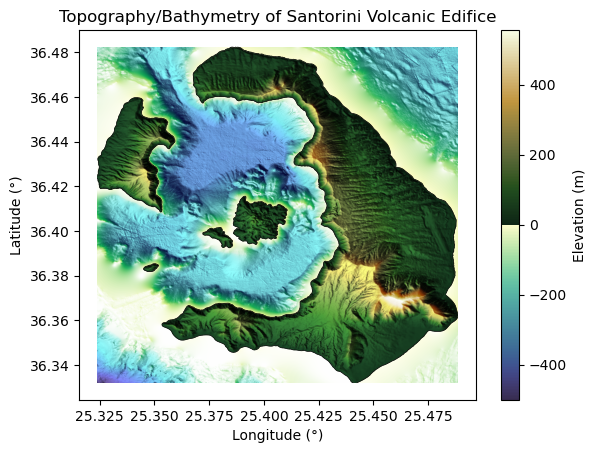

In [36]:
# the edifice is the volcanic structure of santorini. The currently active volancoes lie within the outer caldrea
# set a mask to where the elevation is above sea level (>0)
land_mask = elevation > 0
# use np.where to get the x and y indices where the mask is true
y_indices, x_indices = np.where(land_mask)

# find the max and min to create a bounded box for our zoomed in plot
x_min_idx = x_indices.min()
x_max_idx = x_indices.max()
y_min_idx = y_indices.min()
y_max_idx = y_indices.max()

# slice data based on indices found; new data is used for plotting
elev_zoomed = elevation[y_min_idx:y_max_idx+1, x_min_idx:x_max_idx+1]
x_zoomed = x_elev[x_min_idx:x_max_idx+1]
y_zoomed = y_elev[y_min_idx:y_max_idx+1]

"""
volacnic edifice is the above ground section of a volcano. We know the dormant volcanoes on santorini lie within
the outer caldera, so using np.where we find all points where we are above sea level using a mask. Taking the extremes
of this we form a box around the caldera. This box becomes the limits of our data to plot.
"""
# plot as above, but with the zoomed data

# find absolute maximum; set vmin and vmax to the +/- of this value to centre color map around zero 
max_abs_value = max(abs(elev_zoomed.flatten().min()), abs(elev_zoomed.flatten().max()))
vmin, vmax = -max_abs_value, max_abs_value

# colour map specifcally designed for bathmyerty data
cmap = cmocean.cm.topo

# create figure and axis
fig, ax = plt.subplots()

# plot a dummy variable of the colourmesh and remove; this is to get a colourbar
dummy = plt.pcolormesh(x_zoomed, y_zoomed, elev_zoomed, vmin=vmin, vmax=vmax, cmap=cmap)
dummy.remove()

# add hillshade 
ls = LightSource(azdeg=315, altdeg=45) # from northwest, at a 45 degree angle
# shade the elevation using same cmap as the colorbar and symmetric limits
hillshade = ls.shade(elev_zoomed, cmap=cmap, vmin=vmin, vmax=vmax, blend_mode='overlay') 
# show hillshade, with extent being the extent of the map
ax.imshow(hillshade, extent=[x_zoomed.min(), x_zoomed.max(), y_zoomed.min(), y_zoomed.max()], aspect='auto', origin='lower')

# add coastline using contouring (where elevation=0)
ax.contour(x_zoomed, y_zoomed, elev_zoomed, levels=[0], colors='black', linewidths=0.5)

# add colourbar with limits for only data we plot
cbar = plt.colorbar(dummy, label='Elevation (m)', ax=ax)
cbar.ax.set_ylim(elev_zoomed.flatten().min(), elev_zoomed.flatten().max())

# add labels
plt.title('Topography/Bathymetry of Santorini Volcanic Edifice')
plt.ylabel('Latitude (°)')
plt.xlabel('Longitude (°)')
plt.show()

**Questions:**

- **Fundamentals: [1]** How does the level of detail in the topography vary across the area? Why do you think this is?
- **Core: [1]** Why can't we use a built in feature for the coastline?


**Answer:**

We see that the detail in topography is far greater close to the Santorini caldera, being able to see fine details, and decreases as we move towards deeper waters, especially in the south east. This might be for a few reaosns. Firstly, the caldera and other high detail regions are of more interest so are surveyd in more detail. Alternatively, deeper waters will alter sonar beams, causing a lower accurate resolution, and are also in general harder to survey, and surveyed less frequently.

We cannot use a built in feature for the coastline as they are generalised global datasets. Our topography/bathymetry data is very high resolution, and these generalised coastlines may not match the points where elevation is zero. 

## Section 3: Individual Eruptions

Since the Minoan eruption, Santorini volcano has erupted a number of times, constructing a new edifice in the centre of the caldera, which now includes two islands, Nea Kameni and Palea Kameni. The folder `SantoriniPolygons` contains longitude and latitude data for polygons outlining the flows from a number of these eruptions.

- **Fundamentals: [2]** Choose a single flow and write code to read in the text file. Check that this has been done correctly.
- **Fundamentals: [2]** Plot the shape of the flow on a blank plot (no background topography).
- **Fundamentals: [2]** Use `fill` rather than `plot` to plot a closed polygon, rather than one with a small gap between the first and last point. You can modify your code from the previous two steps rather than making a new copy.
- **Fundamentals: [2]** Use a loop to read in every file in turn and plot it in a different colour. Include a legend. You can modify your code from the previous two steps rather than making a new copy.

In [37]:
# choose to read in the 1950 flow file

# set path to folder and then file
polygons_path = project_data_path + 'SantoriniPolygons/'
file_path = polygons_path + '1950.xy'

# text files can be read by np.loadtxt; ',' separated values in the file, so we set it as delimiter
data = np.loadtxt(file_path, delimiter=',')

# print see form and check loading
print(data)

# we see in printing the data array shape, meaning x, y are extrated as follows
x = data[:,0]
y = data[:,1]

[[25.3970994  36.4041357 ]
 [25.39702282 36.40403895]
 [25.39692217 36.40387962]
 [25.39687678 36.40365363]
 [25.39689578 36.40333776]
 [25.39693132 36.40314973]
 [25.39704275 36.40312884]
 [25.39716812 36.40316366]
 [25.39731343 36.40324266]
 [25.39745245 36.40339515]
 [25.39761069 36.4035312 ]
 [25.39774164 36.40369197]
 [25.39777302 36.40379787]
 [25.39774164 36.40391555]
 [25.3976476  36.40404787]
 [25.39752133 36.4041357 ]
 [25.39740078 36.40419598]
 [25.39725439 36.40424765]
 [25.39720273 36.40422181]]


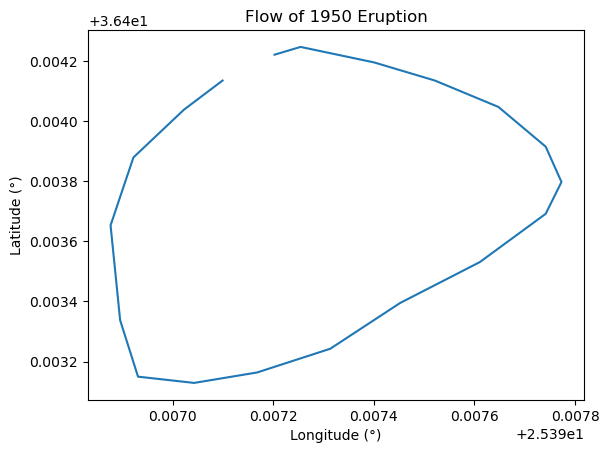

In [38]:
# plot 1950 flow (read above)

plt.plot(x, y)
plt.title('Flow of 1950 Eruption')
plt.ylabel('Latitude (°)')
plt.xlabel('Longitude (°)')
plt.show()

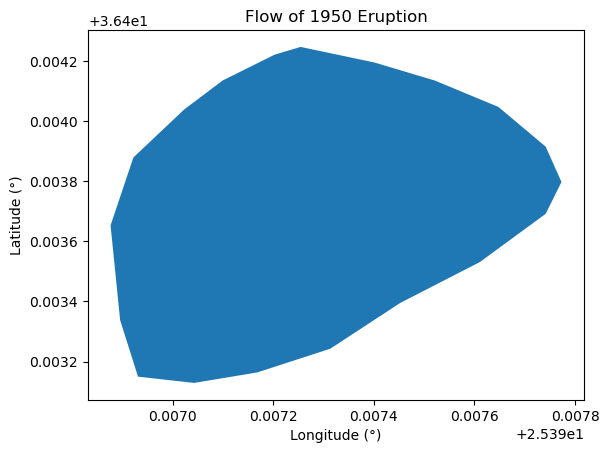

In [39]:
# plot 1950 flow using fill to complete polygon

plt.fill(x, y)
plt.title('Flow of 1950 Eruption')
plt.ylabel('Latitude (°)')
plt.xlabel('Longitude (°)')
plt.show()

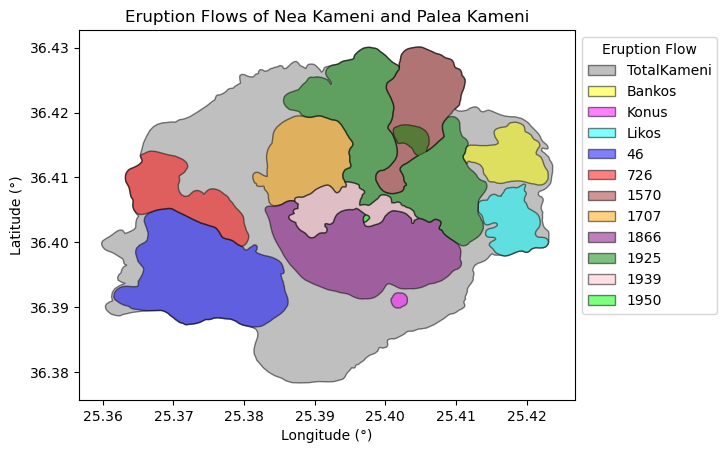

In [40]:
# plot all files overlayed

# set up list tuples of all file names and the colour in which they will be plotted
files_colours = [('TotalKameni.xy', 'gray'),
         ('Bankos.xy', 'yellow'),
         ('Konus.xy', 'magenta'),
         ('Likos.xy', 'cyan'),
         ('46.xy', 'blue'),
         ('726.xy', 'red'),
         ('1570.xy', 'brown'),
         ('1707.xy', 'orange'),
         ('1866.xy', 'purple'),
         ('1925.xy', 'green'),
         ('1939.xy', 'pink'),
         ('1950.xy', 'lime')
        ]

# loop over all files and plot on one figure
fig, ax = plt.subplots(1,1)
for file, colour in files_colours:
    # get data as above
    file_path = polygons_path + file
    data = np.loadtxt(file_path, delimiter=',')
    x = data[:,0]
    y = data[:,1]
    label = file.split('.')[0] # remove .xy extenison for label
    ax.fill(x, y, alpha=0.5, color=colour, edgecolor='black', label=label)

# add labels
plt.title('Eruption Flows of Nea Kameni and Palea Kameni')
plt.ylabel('Latitude (°)')
plt.xlabel('Longitude (°)')
plt.legend(bbox_to_anchor=(1,1), title='Eruption Flow')
plt.show()

- **Fundamentals: [1]** Once you have the plain polygons working, make a version of the figure that includes the topography.

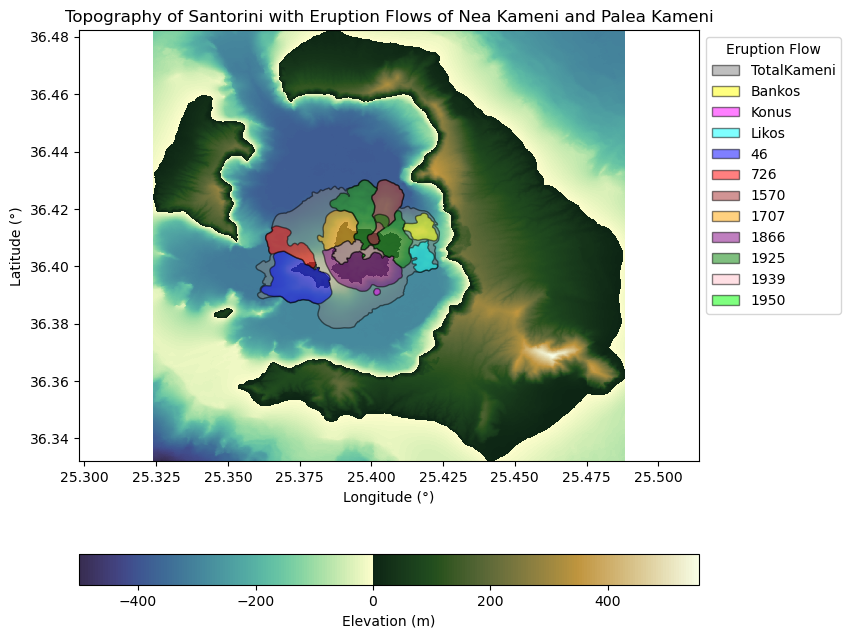

In [41]:
# add topographical data by pcolormesh at low alpha - vmin, vmax, cmap and files_colours defined in above boxes to save memory
# set up plot using zoomed plotting data from section 2
fig, ax = plt.subplots(1,1, figsize=(8,8))

# plot a dummy variable of the colourmesh and remove; this is to get a colourbar
topo = ax.pcolormesh(x_zoomed, y_zoomed, elev_zoomed, vmin=vmin, vmax=vmax, cmap=cmap)

# add colourbar horizontally
cbar = plt.colorbar(topo, label='Elevation (m)', ax=ax, orientation='horizontal')
cbar.ax.set_xlim(elev_zoomed.flatten().min(), elev_zoomed.flatten().max())

# plot flows as above

# loop over all files and plot on one figure
for file, colour in files_colours:
    file_path = polygons_path + file
    data = np.loadtxt(file_path, delimiter=',')
    x = data[:,0]
    y = data[:,1]
    label = file.split('.')[0]
    ax.fill(x, y, alpha=0.5, color=colour, edgecolor='black', label=label)


# add labels 
plt.title('Topography of Santorini with Eruption Flows of Nea Kameni and Palea Kameni')
plt.ylabel('Latitude (°)')
plt.xlabel('Longitude (°)')
plt.legend(bbox_to_anchor=(1,1), loc='upper left', title='Eruption Flow')
ax.axis('equal') # keep ratio to not distort
plt.show()

**Questions:**
- **Fundamentals: [1]** How did you check that the file had been read in correctly?
- **Fundamentals: [2]** Why did we make a plot without the background topography first?
- **Core: [1]** Did you make any stylistic changes to your polygons for the plot with the topography? Why or why not?


**Answer:**

As I selected a file with only 19 entries (1950.xy), I was able to print out the data and then observe that all values were the same as in the raw .txt file. This coupled with no errors or warnings led me to assume the file was read correctly.

We made plots without the background first for a few reasons. Firstly, it allows us to understand the data, in how we read and deal with it, and also what it conveys. It also makes debugging easier - a less complex plot allows us to identify, isolate and fix the issue quicker. For example, when we get to overlaying, we know the issue will not be with the text files or the polygon plotting. Finally, it also allows us to test and identity what colours, alphas, or other customisations work best for the plot.  

I did not end up making any changes. Colours were initially chosen to have high contrast, and this remained in the topogrpahical overlay. Furthermore, these colours were different enough from the colour map of the topogrpahy to still be visible. I did adjust the alpha of the plot, and while higher alphas also work well for the plot, I decided that the initial alpha of 0.5 was most suitable to see detail in both the background and the flows. 

## Section 4: Area of each eruption

We now want to know the area covered by each eruption. We will do this by making a mask showing which points in the topography grid are inside the polygon defined by each flow.

- **Core: [2]** Make a mask for the 46 flow, explaining each line of your code
- **Core: [2]** Test that your mask has worked correctly

In [42]:
# create mask for 46 flow
# load 46 data
file_path = polygons_path + '46.xy' # get filepath to 46 flow
data = np.loadtxt(file_path, delimiter=',') # load data from 46 flow
x_46 = data[:,0] # separate x from data
y_46 = data[:,1] # separate y from data

# create mask
X, Y = np.meshgrid(x_elev, y_elev) # create grid of x and y for all elevation values;
# X and Y respectively contain all x and y values for every row/column combination in the elevation grid
polygon = np.column_stack([x_46, y_46]) # create (x,y) coordinates of polygon boundary
points = np.column_stack([X.flatten(), Y.flatten()]) # X and Y are 2D arrays; flatten both and then stack
# this creates an array (x,y) point pairs for every point in the grid
mask = Path(polygon).contains_points(points).reshape(elevation.shape) # Path is a very useful object class form maptlotlib
# start by creating the Path from our polygon boundary data
# .contains_points() is a method of Path which returns a boolean array checking if 'points' are within the polygon
# finally reshape it back to match the dimensions of elevation

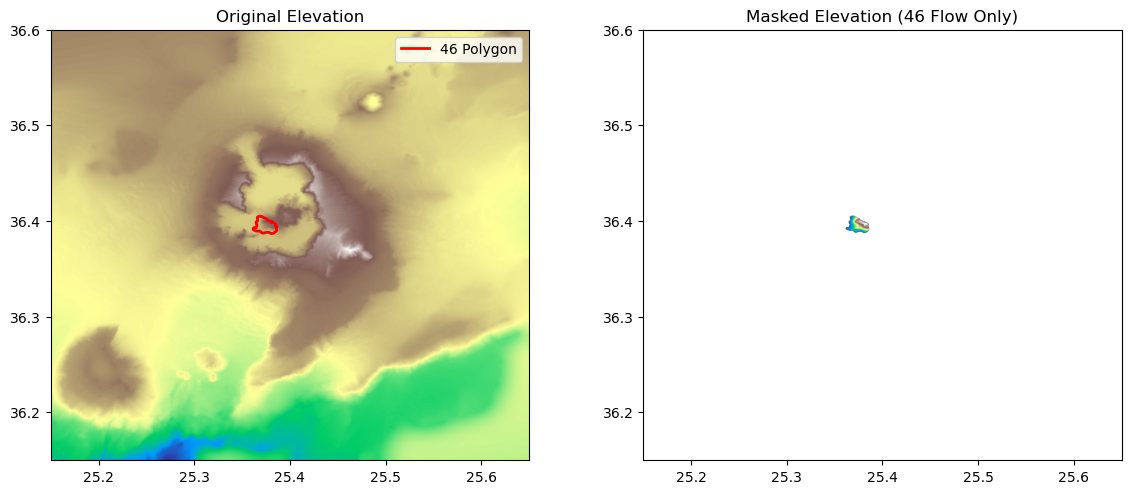

In [43]:
# check mask acts as expected by plotting

# use np.where to include elevation where mask is true, and nan where it is false
# this way of using the mask retains the shape of the array for plotting
elev_masked = np.where(mask, elevation, np.nan)

# check by plot
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# set extent so imshow is on same coordinate extent
extent = [x_elev.min(), x_elev.max(), y_elev.min(), y_elev.max()]

# plot all elevation with 46 polygon
# imshow takes up less memory but is harder to customise - not required as we are just checking mask has worked
ax[0].imshow(elevation, cmap='terrain', origin='lower', extent=extent) 
ax[0].plot(x_46, y_46, color='red', linewidth=2, label='46 Polygon')
ax[0].set_title('Original Elevation')
ax[0].legend()

# plot masked elevation - we see only inside the polygon remains
ax[1].imshow(elev_masked, cmap='terrain', origin='lower', extent=extent)
ax[1].set_title('Masked Elevation (46 Flow Only)')

plt.tight_layout()
plt.show()

- **Core: [2]** Now calculate the area covered by the 46 flow, explaining your work.

From one of my maths courses, I know that for a mathematical function $z(x,y)$, surface area is defined as 
$$\int\int_{R}{\left(\sqrt{1 + \frac{\partial z}{\partial x}^2 + \frac{\partial z}{\partial y}^2}\right)} dxdy \approx \sum_{i} \sum_{j}{\left(\left(\sqrt{1 + \left(\frac{\partial z}{\partial x}\right)_{i,j}^2 + \left(\frac{\partial z}{\partial y}\right)_{i,j}^2}\right)\cdot \Delta x \cdot \Delta y\right)}$$ 
as $\Delta x,\Delta y \rightarrow 0$. We take z to be elevation in metres, and x and y to be the horizontal (lon) and vertical (lat) distances in metres. $i$ and $j$ index each grid cell of our data. We use this sum approximation below to calculate surface area, as our grid cells ($\Delta x$ and $\Delta y$) are very small. I see this as the best way to calculate surface area.

In [44]:
# find difference in adjacent x (longitude) grid entries
dx_c = np.diff(x_elev)[0]
# convert to metres using standard conversion
# cosine is present as spacing of longitude varies based on latitude (in radians)
dx_m = dx_c * 111139 * np.cos(y_elev.mean()*np.pi/180)

# find difference in adjacent y (latitude) grid entries
dy_c = np.diff(y_elev)[0]
# convert to metres using standard conversion
dy_m = dy_c * 111139

# find partial derivates using np.gradient
dz_dy, dz_dx = np.gradient(elevation, dy_m, dx_m)

# using the formula defined above to find cell wise surface area 
# this is the surface area of each individual grid square in square metres
cell_wise_area = np.sqrt(1 + dz_dx**2 + dz_dy**2) * (dx_m*dy_m)

# return array of only values which are inside the polygon (mask is true)
cell_wise_area_masked = cell_wise_area[mask]
# note this is a 1D array, so we only need to sum once to find total area

# sum to find area inside polygon
area_m2 = np.sum(cell_wise_area_masked)
# convert to square km
area_km2 = area_m2 / (1000*1000)

# print final area to 3 d.p.
print(f'Area of flow 46 is {area_km2:.3f}km^2')

Area of flow 46 is 3.069km^2


**Question:**
- **Core: [1]** What is a sensible unit for the area?


- **Core: [2]** Now calculate the area of each flow and build a pandas dataframe containing the name of the flow and its area. Check that the dataframe looks sensible. Make a new section of code for this, rather than editing the code above.

**Answer:**

$\text{km}^2$ is a sensible unit for the area as it is a standard unit and is appropriate to the scale

In [45]:
# set up list of all flows in data
flows = [
    '46.xy',
    '726.xy',
    '1570.xy',
    '1707.xy',
    '1866.xy',
    '1925.xy',
    '1939.xy',
    '1950.xy',
    'Bankos.xy',
    'Konus.xy',
    'Likos.xy',
    'TotalKameni.xy'
]

# initalise list to store each flow data before converting to a data frame
flow_data = []

for flow in flows:
    # create mask as above
    # get flow polygon
    file_path = polygons_path + flow 
    data = np.loadtxt(file_path, delimiter=',') 
    x = data[:,0] 
    y = data[:,1] 
    # create mask
    X, Y = np.meshgrid(x_elev, y_elev) 
    polygon = np.column_stack([x, y])
    points = np.column_stack([X.flatten(), Y.flatten()])
    mask = Path(polygon).contains_points(points).reshape(elevation.shape)

    # calculate area of flow
    # as cell wise area is independant of the flow and already calculated for all cells, we do not have to re run it for every flow
    # we simply sum the area that is included in the mask
    cell_wise_area_masked = cell_wise_area[mask]
    area_m2 = np.sum(cell_wise_area_masked)
    area_km2 = area_m2 / (1000*1000)

    # add entries to data frame
    # get name of flow from stem
    flow_name = flow.split('.')[0]
    # add flow data to data list as a dictionary
    flow_data.append({'Name': flow_name, 'Area': area_km2})

# convert list of dictionaries to data frame
flow_areas = pd.DataFrame(flow_data)
# print to check values are reasonable
print(flow_areas)

           Name       Area
0            46   3.068607
1           726   1.145074
2          1570   1.564847
3          1707   1.471127
4          1866   2.802205
5          1925   3.743308
6          1939   0.695568
7          1950   0.007090
8        Bankos   0.791783
9         Konus   0.046048
10        Likos   0.708178
11  TotalKameni  23.101663


## Section 5: Comparing areas and volumes

The file `SantoriniVolumes.txt` contains estimated eruption volumes for each eruption. It also contains areas for each eruption.

- **Fundamentals: [1]** Read the file into a pandas dataframe.
- **Advanced: [2]** Make a plot of your areas versus the supplied areas. Include a 1 to 1 correspondence line.
- **Advanced: [2]** What is the correlation coefficient between them? Is there a pattern to the differences?
- **Advanced: [1]** Make a plot of your areas versus the supplied volumes.
- **Advanced: [1]** What is the correlation coefficient between them? How confident would you be estimating the volume of an eruption for which you only had an area?


In [46]:
# read file into pandas dataframe
# set up filepath
file_path = project_data_path + 'SantoriniVolumes.txt'

# read file as csv
area_volume_df = pd.read_csv(file_path)

# check loading
area_volume_df.head()

,Name,Area(km^2),Volume(km^3),Ave.Thickness(m)
0,1950,0.005655,0.000014,2.419974
1,1939,0.630831,0.011088,17.577068
2,1925,3.186270,0.135145,42.414915
3,1866,2.522580,0.197314,78.219260
4,1707,1.282930,0.094570,73.713917


In [47]:
# clean both exact df and found areas df for the questions required

# set index of exact values to name and rename columns
exact_flow_df = area_volume_df.set_index('Name')
exact_flow_df.columns = ['Exact Area', 'Exact Volume', 'Ave.Thickness']
# check
print(exact_flow_df.head())

# set index of calculated values to name
calculated_flow_df = flow_areas.set_index('Name')
calculated_flow_df.columns = ['Calculated Area']
# check
print(calculated_flow_df.head())

      Exact Area  Exact Volume  Ave.Thickness
Name                                         
1950    0.005655      0.000014       2.419974
1939    0.630831      0.011088      17.577068
1925    3.186270      0.135145      42.414915
1866    2.522580      0.197314      78.219260
1707    1.282930      0.094570      73.713917
      Calculated Area
Name                 
46           3.068607
726          1.145074
1570         1.564847
1707         1.471127
1866         2.802205


In [48]:
# create combined df of both results
# use inner join to only have flows represented in both dataframes
flows_df = pd.concat([calculated_flow_df, exact_flow_df], join='inner', axis=1)
# check
print(flows_df)

        Calculated Area  Exact Area  Exact Volume  Ave.Thickness
Name                                                            
46             3.068607    2.621060      0.172220      65.706256
726            1.145074    0.985622      0.017937      18.198569
1570           1.564847    1.258930      0.055153      43.809599
1707           1.471127    1.282930      0.094570      73.713917
1866           2.802205    2.522580      0.197314      78.219260
1925           3.743308    3.186270      0.135145      42.414915
1939           0.695568    0.630831      0.011088      17.577068
1950           0.007090    0.005655      0.000014       2.419974
Bankos         0.791783    0.688497      0.036340      52.781300
Konus          0.046048    0.039863      0.000599      15.018616
Likos          0.708178    0.550254      0.014099      25.622414


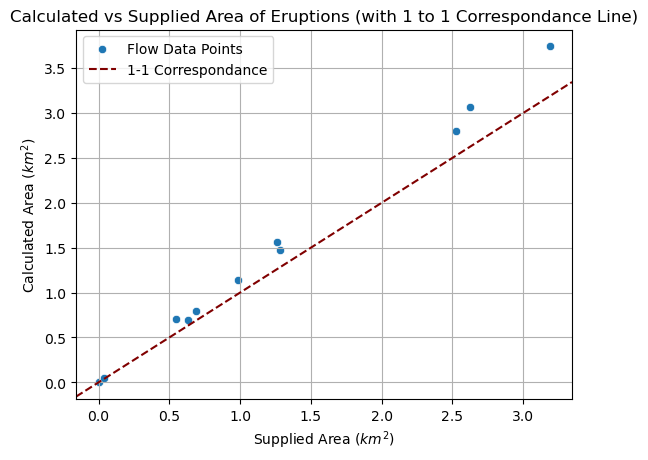

In [49]:
# plot of calculated vs supplied areas with 1-1 correspondance line

# plot data using scatter plot
sns.scatterplot(y='Calculated Area', x='Exact Area', data=flows_df, label='Flow Data Points')

# plot 1-1 correspondance (y=x)
plt.axline((0,0), slope=1, color='maroon', linestyle='--', label='1-1 Correspondance')

# customise plot and add labels
plt.title('Calculated vs Supplied Area of Eruptions (with 1 to 1 Correspondance Line)')
plt.xlabel(r'Supplied Area ($km^2$)')
plt.ylabel(r'Calculated Area ($km^2$)')
plt.grid()
plt.legend()
plt.show()

In [50]:
# calculate correlation coefficient for supplied and calculated areas
r = np.corrcoef(flows_df['Calculated Area'], flows_df['Exact Area'])[0, 1]
print(r)

0.9988576221297712


As we can see, the correlation coefficient between the calculated and supplied is extremely close to 1 ($\approx 0.9989$), suggesting a strong linear relationship. However, from the graph we see that this is not a 1 to 1 correspondance, as calculated values are consistently larger than the supplied. This would suggest a pattern to differences, likely a systematic bias.

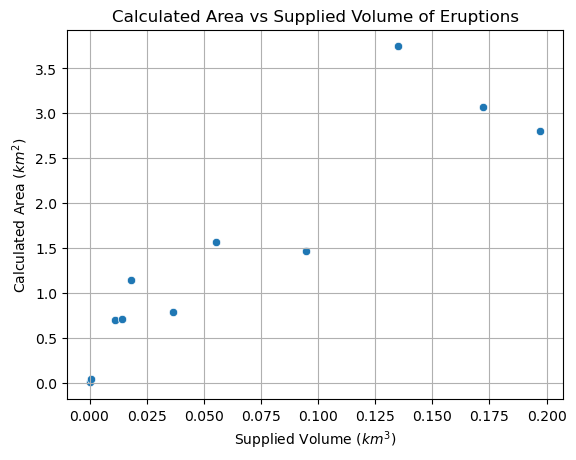

In [51]:
# plot of calculated vs volume

# plot data using scatter plot
sns.scatterplot(y='Calculated Area', x='Exact Volume', data=flows_df)

# customise plot and add labels
plt.title('Calculated Area vs Supplied Volume of Eruptions')
plt.xlabel(r'Supplied Volume ($km^3$)')
plt.ylabel(r'Calculated Area ($km^2$)')
plt.grid()
plt.show()

In [52]:
# calculate correlation coefficient for supplied volume and calculated area
r = np.corrcoef(flows_df['Calculated Area'], flows_df['Exact Volume'])[0, 1]
print(r)

0.9049514150106223


The correlation coefficient of approximately $0.905$ suggests a very strong linear relationship between calculated areas and volume. Therefore, upon fitting a linear model I would be very confident in being able to estimate the volume of a flow given only its area.